In [6]:
import os
import sys
import numpy as np
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolAlign
import py3Dmol
from IPython.display import display

# Import our custom kernel
sys.path.append(os.path.abspath("."))
from wcs_gnccp import WCS_GNCCP


In [7]:
# Load two Active molecules
sdf_path = Path("../Data/Aromatase_actives_new.sdf")
supplier = Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=True)

mols = []
for mol in supplier:
    if mol is not None:
        mols.append(mol)
    if len(mols) == 2:
        break

mol1_3d = mols[0]
mol2_3d = mols[1]

# Convert copies to 2D for the topological mapping
mol1_2d = Chem.Mol(mol1_3d)
mol1_2d.RemoveAllConformers()
AllChem.Compute2DCoords(mol1_2d)

mol2_2d = Chem.Mol(mol2_3d)
mol2_2d.RemoveAllConformers()
AllChem.Compute2DCoords(mol2_2d)

print("Molecules loaded successfully!")


Molecules loaded successfully!


In [8]:
# Run the WCS 2D Graph Kernel
matcher = WCS_GNCCP(alpha=0.7, max_iter=8, fw_max_iter=8)

L = min(mol1_2d.GetNumAtoms(), mol2_2d.GetNumAtoms()) - 2
print(f"Searching for {L} mapping points...")

_, matches, score = matcher.match(mol1_2d, mol2_2d, L=L, verbose=False)
print(f"Mapping Complete! Similarity Score: {score:.3f}")


Searching for 56 mapping points...
Mapping Complete! Similarity Score: 0.629


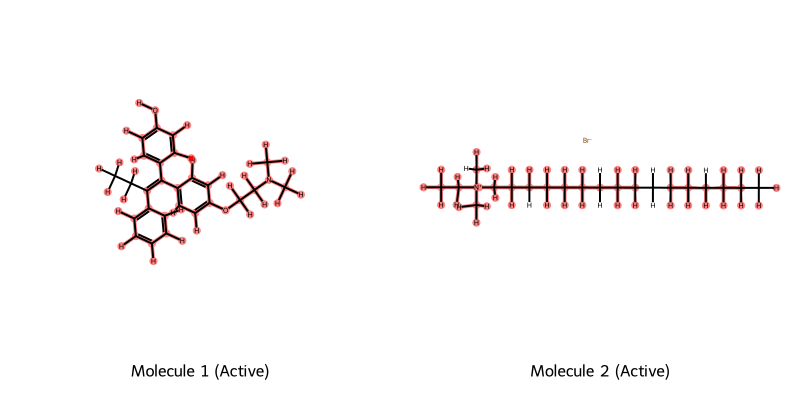

In [9]:
# Visualize the 2D Topological Mapping
matched_atoms1 = [m[0] for m in matches]
matched_atoms2 = [m[1] for m in matches]

img = Draw.MolsToGridImage(
    [mol1_2d, mol2_2d], 
    molsPerRow=2, 
    subImgSize=(400, 400),
    highlightAtomLists=[matched_atoms1, matched_atoms2],
    legends=["Molecule 1 (Active)", "Molecule 2 (Active)"]
)
display(img)


In [ ]:
# 3D Interactive Visualization - Side by Side Mapping

import copy
mol1_viz = copy.deepcopy(mol1_3d)
mol2_viz = copy.deepcopy(mol2_3d)

# 1. Shift Molecule 2 to the right by 15 Angstroms so they sit side-by-side
conf2 = mol2_viz.GetConformer()
for i in range(mol2_viz.GetNumAtoms()):
    pos = conf2.GetAtomPosition(i)
    conf2.SetAtomPosition(i, Chem.rdGeometry.Point3D(pos.x + 15.0, pos.y, pos.z))

# 2. Extract MolBlocks
mb1 = Chem.MolToMolBlock(mol1_viz)
mb2 = Chem.MolToMolBlock(mol2_viz)

# 3. Render interactively in Jupyter
view = py3Dmol.view(width=900, height=500)
view.addModel(mb1, 'sdf')
view.setStyle({'model': 0}, {'stick': {'color': 'lightgreen'}})

view.addModel(mb2, 'sdf')
view.setStyle({'model': 1}, {'stick': {'color': 'cyan'}})

# 4. Draw connecting lines between the matched atoms!
conf1 = mol1_viz.GetConformer()
for m in matches:
    idx1 = m[0] # Atom in Mol 1
    idx2 = m[1] # Atom in Mol 2
    
    pos1 = conf1.GetAtomPosition(idx1)
    pos2 = conf2.GetAtomPosition(idx2)
    
    # Draw a thin cylinder mapping the atom in Mol 1 to Mol 2
    view.addCylinder({
        'start': {'x': pos1.x, 'y': pos1.y, 'z': pos1.z},
        'end': {'x': pos2.x, 'y': pos2.y, 'z': pos2.z},
        'radius': 0.05,
        'color': 'yellow',
        'dashed': True
    })

print("Showing Mol 1 (Left) mapped to Mol 2 (Right)")
view.zoomTo()
view.show()


Showing Mol 1 (Left) mapped to Mol 2 (Right)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

: 